# **Import Libraries**

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Define Project Directories**

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

SAVE_DIR = os.path.join(PROJECT_DIR, "saved_objects")

MODEL_DIR = os.path.join(PROJECT_DIR, "models")

print(PROJECT_DIR)

/content/drive/MyDrive/AI-TeleTriage-System


# **Load Saved Objects**

In [4]:
with open(os.path.join(SAVE_DIR, "train_df.pkl"), "rb") as f:
    train_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "val_df.pkl"), "rb") as f:
    val_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "test_df.pkl"), "rb") as f:
    test_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "class_weights.pkl"), "rb") as f:
    class_weights = pickle.load(f)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 10)
(1502, 10)
(1503, 10)


# **Load Dataset**

In [5]:
import os

# Remove old link/folder if it exists
if os.path.exists("dataset"):
    !rm -rf dataset

# Create symbolic link
!ln -s /content/drive/MyDrive/AI-TeleTriage-System/dataset dataset

print("Dataset linked successfully!")

Dataset linked successfully!


In [6]:
!ls dataset

ham10000_images_part_1	HAM10000_metadata.csv  hmnist_8_8_RGB.csv
HAM10000_images_part_1	hmnist_28_28_L.csv     skin-cancer-mnist-ham10000.zip
ham10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_2	hmnist_8_8_L.csv


In [7]:
!cp -r /content/drive/MyDrive/AI-TeleTriage-System/dataset .

cp: '/content/drive/MyDrive/AI-TeleTriage-System/dataset' and './dataset' are the same file


In [8]:
!ls dataset

ham10000_images_part_1	HAM10000_metadata.csv  hmnist_8_8_RGB.csv
HAM10000_images_part_1	hmnist_28_28_L.csv     skin-cancer-mnist-ham10000.zip
ham10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_2	hmnist_8_8_L.csv


# **Verify a path from your DataFrame**

In [9]:
print(train_df["path"].iloc[0])

/content/drive/MyDrive/AI-TeleTriage-System/dataset/ham10000_images_part_2/ISIC_0031775.jpg


In [10]:
import os

os.path.exists(train_df["path"].iloc[0])

True

# **Create ImageDataGenerators**

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="disease",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="disease",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="disease",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


# **Import everything for DenseNet121**

In [13]:
import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization,
    Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# **Build the DenseNet121 model**

We'll use the standard transfer learning approach:

* DenseNet121 pretrained on ImageNet
* Freeze the pretrained backbone initially
* Add our own classifier head

In [14]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

inputs = Input(shape=(128,128,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(7, activation="softmax")(x)

model = Model(inputs, outputs)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,799 (27.87 MB)

 Trainable params: 266,247 (1.02 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

# **Compile the Model**

In [15]:
#Use a small learning rate because we're training only the classifier head.
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# **Callbacks**

In [16]:
import os

MODEL_DIR = "/content/drive/MyDrive/AI-TeleTriage-System/models"
os.makedirs(MODEL_DIR, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "densenet121_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# **Train Phase 1**

In [17]:
#Use the class weights from Notebook 1.
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.3081 - loss: 3.6875 - precision: 0.3395 - recall: 0.1370 
Epoch 1: val_accuracy improved from None to 0.68509, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2515s 23s/step - accuracy: 0.4180 - loss: 3.0664 - precision: 0.5314 - recall: 0.2454 - val_accuracy: 0.6851 - val_loss: 1.2351 - val_precision: 0.8493 - val_recall: 0.3715 - learning_rate: 1.0000e-04
Epoch 2/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5938 - loss: 2.2520 - precision: 0.7258 - recall: 0.4797
Epoch 2: val_accuracy improved from 0.68509 to 0.69707, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras
110/110 ━━━━━━━━━

| Metric               |       Result |
| -------------------- | -----------: |
| Training Accuracy    |    **68.62%** |
| Validation Accuracy  | **73.10%** ✅ |
| Validation Precision |   **80.03%** |
| Validation Recall    |   **66.18%** |
| Best Epoch           |       **11** |

Compared to your custom CNN:

Custom CNN: ~51% validation accuracy
DenseNet121 (Frozen): 73.10% validation accuracy

That's a ~23% improvement.

# **Phase 2: Fine-Tuning**

In [ ]:
#This is where DenseNet usually improves the most.

**Unfreeze only the last layers**

In [18]:
# Unfreeze only the last 40 layers
#Create a new cell after training.
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

print("Trainable layers:",
      sum([layer.trainable for layer in base_model.layers]))

Trainable layers: 40


**Recompile**

In [19]:
#Use a much smaller learning rate.
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

**Train again**

In [20]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6836 - loss: 1.3483 - precision: 0.7707 - recall: 0.6231
Epoch 1: val_accuracy improved from 0.73103 to 0.73369, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 737s 6s/step - accuracy: 0.6856 - loss: 1.3770 - precision: 0.7695 - recall: 0.6250 - val_accuracy: 0.7337 - val_loss: 0.8598 - val_precision: 0.8101 - val_recall: 0.6644 - learning_rate: 1.0000e-05
Epoch 2/6
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6788 - loss: 1.3693 - precision: 0.7722 - recall: 0.6191
Epoch 2: val_accuracy did not improve from 0.73369
110/110 ━━━━━━━━━━━━━━━━━━━━ 656s 6s/step - accuracy: 0.6840 - loss: 1.3555 - precision: 0.7761 - recall: 0.6245 - val_accuracy: 0.7317 - val_loss: 0.8662 - val_precision: 0.8104 - val_recall: 0.6658 - learning_rate: 1.0000e

**Why only the last 40 layers?**

DenseNet has learned excellent generic image features from ImageNet.

We only want to adapt the high-level layers to skin lesions.

If we unfreeze everything immediately:

❌ slower training<br>
❌ more overfitting<br>
❌ sometimes lower accuracy

Unfreezing the last 30–50 layers is a standard and effective strategy.

The best-performing model after fine-tuning was obtained at:

Epoch 1
Validation Accuracy: 73.37%
Validation Loss: 0.8598

Subsequent epochs did not improve performance, and the model restored the weights from this best epoch.

**Effectiveness of Fine-Tuning**<br>
Fine-tuning produced only a very modest improvement over the frozen DenseNet121 model.

| Metric                   | Phase 1    | Phase 2    |
| ------------------------ | ---------- | ---------- |
| Best Validation Accuracy | **73.10%** | **73.37%** |
| Validation Precision     | ~80%       | ~81%       |
| Validation Recall        | 66.18%     | 67.04%     |

The improvement in validation accuracy was only 0.27 percentage points, indicating that most of the discriminative features had already been learned during the first phase of transfer learning.

Both ReduceLROnPlateau and EarlyStopping confirmed that the model had reached an optimal point early in the fine-tuning process.


# **Load the best saved model**

In [21]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/AI-TeleTriage-System/models/densenet121_best.keras"
)

# **Evaluate on Test Set**

In [22]:
test_results = best_model.evaluate(test_generator, verbose=1)

print(f"Test Loss      : {test_results[0]:.4f}")
print(f"Test Accuracy  : {test_results[1]:.4f}")
print(f"Test Precision : {test_results[2]:.4f}")
print(f"Test Recall    : {test_results[3]:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 419s 17s/step - accuracy: 0.7152 - loss: 0.9106 - precision: 0.8121 - recall: 0.6414
Test Loss      : 0.9106
Test Accuracy  : 0.7152
Test Precision : 0.8121
Test Recall    : 0.6414


**Comparing validation and test performance:**

| Metric    | Validation |       Test |
| --------- | ---------: | ---------: |
| Accuracy  | **73.37%** | **71.52%** |
| Precision | **81.01%** | **81.21%** |
| Recall    | **67.04%** | **64.14%** |


The test accuracy is only about 1.8 percentage points lower than the best validation accuracy, indicating that the model generalizes well and does not suffer from severe overfitting.

Similarly, precision remains almost unchanged, while recall decreases only slightly, further confirming the robustness of the trained model.

# **Predict Test Images**

In [23]:
import numpy as np

pred_prob = best_model.predict(test_generator)

pred_classes = np.argmax(pred_prob, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

24/24 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step


# **Classification Report**

In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names,
    digits=4
))

                      precision    recall  f1-score   support

   Actinic Keratosis     0.3253    0.5510    0.4091        49
Basal Cell Carcinoma     0.4667    0.3636    0.4088        77
    Benign Keratosis     0.4074    0.4000    0.4037       165
      Dermatofibroma     0.1096    0.4706    0.1778        17
    Melanocytic Nevi     0.8495    0.9254    0.8858      1006
            Melanoma     0.0000    0.0000    0.0000       167
     Vascular Lesion     0.5172    0.6818    0.5882        22

            accuracy                         0.7152      1503
           macro avg     0.3822    0.4846    0.4105      1503
        weighted avg     0.6566    0.7152    0.6821      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* The overall accuracy (71.52%) indicates that the model correctly classified approximately seven out of every ten test images.<br>
* The weighted average F1-score (68.21%) reflects good overall performance because it accounts for the class imbalance.<br>
* However, the macro-average F1-score (41.05%) is substantially lower, showing that the model performs inconsistently across different classes.<br>
* The gap between weighted and macro averages indicates that the model is strongly influenced by the dominant Melanocytic Nevi class while underperforming on minority classes.

# **Confusion Matrix**

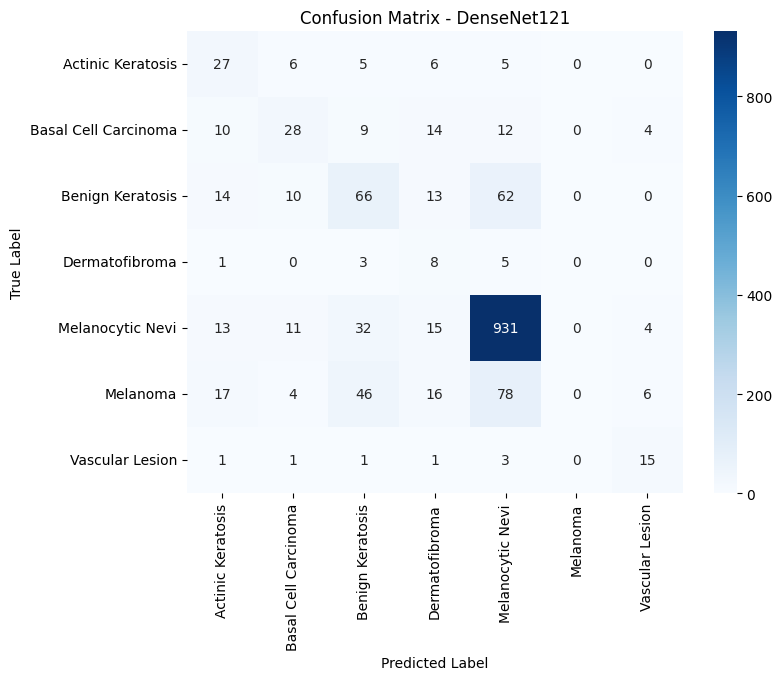

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DenseNet121")

plt.show()

**The confusion matrix highlights several important observations:**

* The model performs exceptionally well for the dominant Melanocytic Nevi class, correctly classifying 931 of 1006 images.
* Moderate classification performance is observed for Actinic Keratosis, Basal Cell Carcinoma, Benign Keratosis, Dermatofibroma, and Vascular Lesion.
* The model exhibits poor performance for Melanoma, confusing almost all Melanoma images with Melanocytic Nevi and Benign Keratosis.
* This behavior reflects the strong class imbalance present in the HAM10000 dataset, where the model becomes biased toward the majority class.

# **Accuracy Score**

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_classes, pred_classes)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7152


# **Precision, Recall, F1 Score**

In [27]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    true_classes,
    pred_classes,
    average="weighted"
)

recall = recall_score(
    true_classes,
    pred_classes,
    average="weighted"
)

f1 = f1_score(
    true_classes,
    pred_classes,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.6566
Recall    : 0.7152
F1 Score  : 0.6821


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **ROC Curve (Multiclass)**

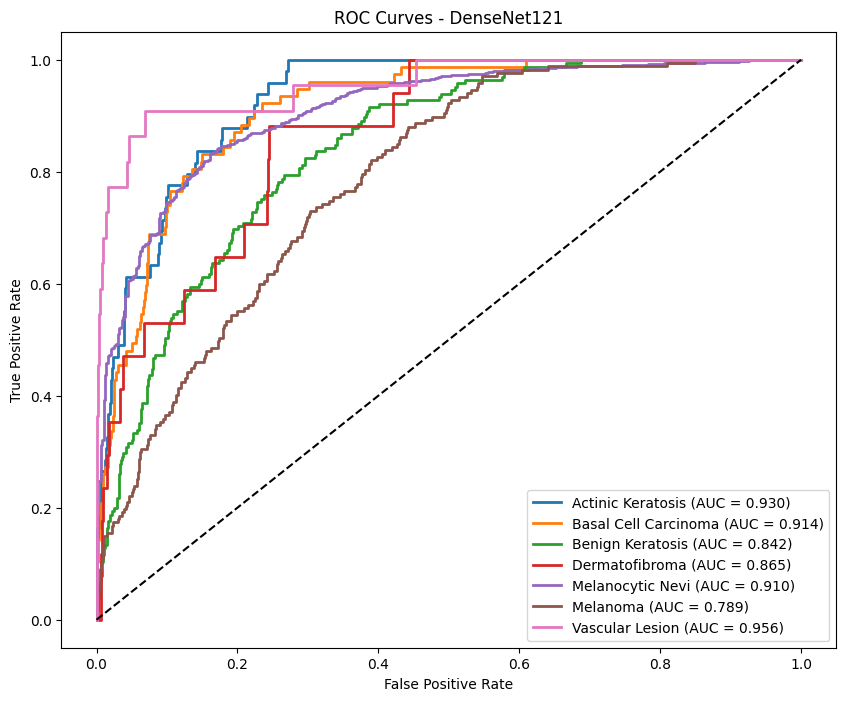

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

true_binary = label_binarize(
    true_classes,
    classes=range(n_classes)
)

plt.figure(figsize=(10,8))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        true_binary[:, i],
        pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves - DenseNet121")

plt.legend(loc="lower right")

plt.show()

**The ROC analysis demonstrated good discriminative ability for most lesion categories. DenseNet121 achieved AUC values above 0.90 for Actinic Keratosis (0.930), Basal Cell Carcinoma (0.914), Melanocytic Nevi (0.910), and Vascular Lesion (0.956). Benign Keratosis (0.842) and Dermatofibroma (0.865) also showed satisfactory performance. Melanoma obtained the lowest AUC (0.789), indicating comparatively weaker discrimination. Although ROC performance remained acceptable, the classification report revealed poor melanoma recall due to severe class imbalance and frequent misclassification as Melanocytic Nevi.**

# **Plot Training Curves**

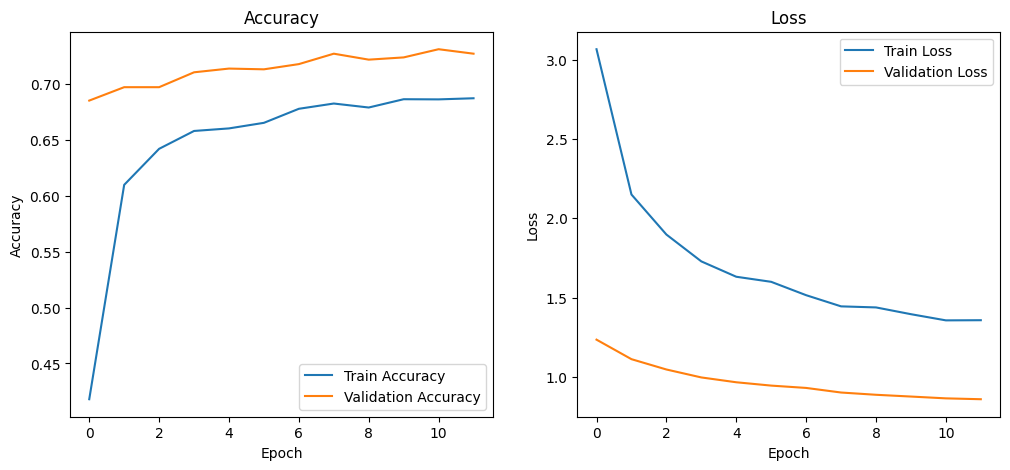

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**The training and validation accuracy increase steadily over the epochs, while both training and validation loss decrease consistently, indicating that the model is learning effectively. The validation accuracy remains slightly higher than the training accuracy, which can occur due to regularization techniques such as dropout. Since the validation loss does not increase and both curves follow a similar trend, there is no evidence of overfitting. Overall, the model demonstrates stable learning and good generalization performance, though the moderate training accuracy suggests there is still room for further improvement through additional tuning or training.**

# **Save Training History**

In [30]:
import pickle
import os

SAVE_DIR = "/content/drive/MyDrive/AI-TeleTriage-System/saved_objects"

with open(os.path.join(SAVE_DIR, "densenet_history.pkl"), "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved successfully.")

Training history saved successfully.
